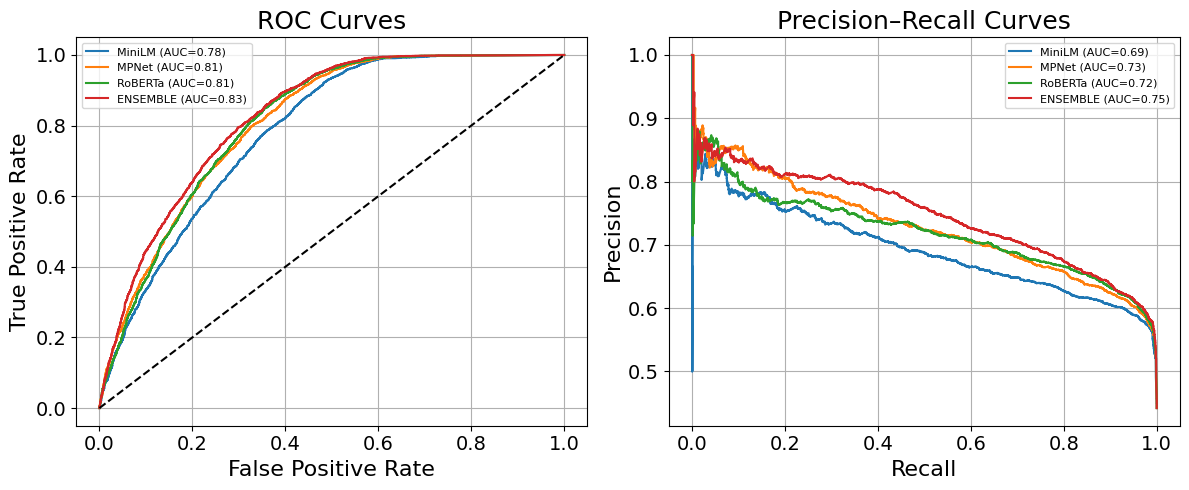

'evaluators = [\n    "prediction_all-MiniLM-L6-v2[chunked]_judge",\n    "prediction_all-mpnet-base-v2[chunked]_judge",\n    "prediction_all-roberta-large-v1[chunked]_judge",\n]\n\ndf_eval_table = build_evaluator_comparison_table(\n    df,\n    evaluators,\n    ground_truth="human_ensemble_judge",\n    n_bootstrap=1000\n)\n\nprint(df_eval_table)'

In [3]:
import pandas as pd
from statsmodels.stats.inter_rater import fleiss_kappa
import numpy as np
from sklearn.metrics import (cohen_kappa_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, matthews_corrcoef,precision_recall_curve, roc_curve, auc)
import os
import matplotlib.pyplot as plt


"""   

Copyright (c) 2026, Michael Tchuindjang
All rights reserved.

This code was developed as part of a PhD research project in Cybersecurity and Artificial Intelligence, 
supported by a studentship at the University of the West of England (UWE Bristol).

Use of this software is permitted for academic, educational, and research purposes.  
For any commercial use or redistribution, please contact the author for permission.

Disclaimer:
In no event shall the author or UWE be liable for any claim, damages, or other liability arising from the use of this code.

Acknowledgment of the author and the research context is appreciated in any derivative work or publication.


"""

# =========================
# GLOBAL PARAMETERS
# =========================
INPUT_FILE = "Results_all_models.csv"

# =========================
# HELPER: CASE-INSENSITIVE FILTER
# =========================
def normalize_filter(values):
    if isinstance(values, str):
        return [values.lower()]
    return [v.lower() for v in values]

# =========================
# COMPUTE DETAILED METRICS
# =========================
def compute_judge_metrics(df, ground_truth="human_ensemble_judge",
                          model_filter=None,
                          turn_depth_filter=None,
                          tense_filter=None,
                          subtopic_filter=None,
                          source_filter=None,
                          attack_type_filter=None,
                          judge_filter=None,
                          metrics_filter=None):

    df_filtered = df.copy()

    df_filtered["subtopic_norm"] = df_filtered["subtopic"].str.lower()

    # =========================
    # APPLY FILTERS
    # =========================
    if model_filter is not None:
        df_filtered = df_filtered[df_filtered['model_name'].isin([model_filter] if isinstance(model_filter,str) else model_filter)]

    if turn_depth_filter is not None:
        df_filtered = df_filtered[df_filtered['turn_depth'].isin([turn_depth_filter] if isinstance(turn_depth_filter,int) else turn_depth_filter)]

    if tense_filter is not None:
        df_filtered = df_filtered[df_filtered['tense'].isin([tense_filter] if isinstance(tense_filter,str) else tense_filter)]

    if subtopic_filter is not None:
        if isinstance(subtopic_filter, str):
            subtopic_filter = [subtopic_filter]
        subtopic_filter_norm = [s.lower() for s in subtopic_filter]
        df_filtered = df_filtered[df_filtered["subtopic_norm"].isin(subtopic_filter_norm)]

    if source_filter is not None:
        df_filtered = df_filtered[df_filtered['source'].isin([source_filter] if isinstance(source_filter,str) else source_filter)]

    if attack_type_filter is not None:
        df_filtered = df_filtered[df_filtered['source'].isin([attack_type_filter] if isinstance(attack_type_filter,str) else attack_type_filter)]

    # =========================
    # JUDGE SELECTION
    # =========================
    judge_cols = [c for c in df_filtered.columns if c.endswith("_judge") and c != ground_truth]
    #print(judge_cols)
    if judge_filter is not None:
        judge_cols = [j for j in judge_cols if j in judge_filter]
       

    metrics_list = []

    # =========================
    # GROUPING (FIXED)
    # =========================
    grouped = df_filtered.groupby(
        ["model_name", "turn_depth", "tense", "subtopic_norm", "source", "attack_name"]
    )

    for (model_name, turn_depth, tense, subtopic_norm, source, attack_name), df_group in grouped:

        # Use normalized subtopic (consistent output)
        subtopic_label = subtopic_norm

        for judge in judge_cols:

            df_valid = df_group[[ground_truth, judge, f"confidence_{judge}"]].dropna()
            if df_valid.empty:
                continue
        
            y_true = df_valid[ground_truth]
            y_pred = df_valid[judge]
        
            # -------------------------
            # CONFIDENCE SCORES (NEW)
            # -------------------------
            y_score = df_valid[f"confidence_{judge}"]
        
            # -------------------------
            # CONFUSION MATRIX
            # -------------------------
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        
            total_rows = len(df_valid)
            total_success = y_pred.sum()
            asr = (tp + fn) / total_rows * 100
        
            # -------------------------
            # FPR / FNR
            # -------------------------
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
            fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        
            # -------------------------
            # ROC AUC (CORRECT VERSION)
            # -------------------------
            try:
                roc_auc = roc_auc_score(y_true, y_score)
            except ValueError:
                roc_auc = None
        
            # -------------------------
            # PR AUC (NEW REQUIREMENT)
            # -------------------------
            try:
                precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_score)
                pr_auc = auc(recall_curve, precision_curve)
            except ValueError:
                pr_auc = None
        
            # -------------------------
            # MCC
            # -------------------------
            try:
                mcc = matthews_corrcoef(y_true, y_pred)
            except ValueError:
                mcc = None
        
            metrics_dict = {
                "Judge": judge,
                "Model": model_name,
                "Turn Depth": turn_depth,
                "Tense": tense,
                "Subtopic": subtopic_label,
                "Source": source,
                "Attack Type": attack_name,
        
                "Total of Success (1s)": total_success,
                "Total of Rows": total_rows,
                "ASR (%)": round(asr, 2),
        
                "Cohen's Kappa": round(cohen_kappa_score(y_true, y_pred), 3),
                "Accuracy": round(accuracy_score(y_true, y_pred), 3),
                "Precision": round(precision_score(y_true, y_pred, zero_division=0), 3),
                "Recall": round(recall_score(y_true, y_pred, zero_division=0), 3),
        
                "F1 (weighted)": round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 3),
                "F1 (macro)": round(f1_score(y_true, y_pred, average='macro', zero_division=0), 3),
        
                "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        
                "FPR": round(fpr, 3),
                "FNR": round(fnr, 3),
        
                # -------------------------
                # NEW METRICS (REVIEWER)
                # -------------------------
                "ROC AUC": round(roc_auc, 3) if roc_auc is not None else None,
                "PR AUC": round(pr_auc, 3) if pr_auc is not None else None,
        
                "MCC": round(mcc, 3) if mcc is not None else None
            }

            if metrics_filter is not None:
                keep_cols = ["Judge","Model","Turn Depth","Tense","Subtopic","Source", "Attack Type"]
                metrics_dict = {k: v for k, v in metrics_dict.items() if k in metrics_filter or k in keep_cols}

            metrics_list.append(metrics_dict)

    return pd.DataFrame(metrics_list)


# =========================
# AGGREGATION FUNCTION
# =========================
def aggregate_metrics(df_metrics,
                      aggregate_by=["Model","Turn Depth","Tense","Subtopic","Source", "Attack Type"]):
    """
    Aggregates metrics based on selected grouping fields.

    Parameters:
    - df_metrics: output from compute_judge_metrics()
    - aggregate_by: list of columns to group by

    Returns:
    - Aggregated DataFrame
    """

    grouped = df_metrics.groupby(aggregate_by)

    agg_rows = []

    for name, group in grouped:
        if not isinstance(name, tuple):
            name = (name,)

        agg_dict = dict(zip(aggregate_by, name))

        # Sum totals
        if "Total of Success (1s)" in group.columns:
            agg_dict["Total of Success (1s)"] = group["Total of Success (1s)"].sum()
        if "Total of Rows" in group.columns:
            agg_dict["Total of Rows"] = group["Total of Rows"].sum()

        # Average performance metrics
        for m in ["ASR (%)","Accuracy","Recall","F1 (weighted)","F1 (macro)","Precision","Cohen's Kappa","FPR","FNR","MCC","ROC AUC","PR AUC"]:
            if m in group.columns:
                agg_dict[m] = round(group[m].mean(), 3)

        # Sum confusion matrix counts
        for m in ["TP","FP","FN","TN"]:
            if m in group.columns:
                agg_dict[m] = group[m].sum()

        agg_rows.append(agg_dict)

    return pd.DataFrame(agg_rows)


def plot_roc_pr_curves(df, selected_judges, ground_truth="human_ensemble_judge"):

    plt.figure(figsize=(12, 5))

    # =========================
    # ROC CURVES
    # =========================
    plt.subplot(1, 2, 1)

    for judge in selected_judges:

        if "gpt" in judge.lower() and judge in df.columns:
            conf_col = judge
        elif "ensemble" in judge.lower():
            # Ensemble: use averaged embedding probabilities
            conf_col = "prob_jailbreak_ensemble"
        
            # Create soft ensemble probability if it does not exist
            if conf_col not in df.columns:
                df[conf_col] = (
                    df["prob_jailbreak_all-MiniLM-L6-v2[no_chunk]"] +
                    df["prob_jailbreak_all-mpnet-base-v2[no_chunk]"] +
                    df["prob_jailbreak_all-roberta-large-v1[no_chunk]"]
                ) / 3
        else:
            conf_col = judge.replace("prediction_", "").replace("_judge", "")
            #conf_col = f"confidence_{conf_col}"
            conf_col = f"prob_jailbreak_{conf_col}"
        
        if conf_col not in df.columns:
            continue
        
        
        df_valid = df[
            [
                ground_truth,
                conf_col
            ]
        ].dropna()
        
        
        if df_valid.empty:
            continue
        
        
        y_true = df_valid[ground_truth].values
        y_score = df_valid[conf_col].values
        
        
        fpr, tpr, _ = roc_curve(
            y_true,
            y_score
        )
        roc_auc = auc(fpr, tpr)

        #plt.plot(fpr, tpr, label=f"{judge} (AUC={roc_auc:.2f})")

        if "all-MiniLM-L6-v2" in judge:
            display_name = "MiniLM"
        elif "all-mpnet-base-v2" in judge:
            display_name = "MPNet"
        elif "all-roberta-large-v1" in judge:
            display_name = "RoBERTa"
        elif "ensemble" in judge:
            display_name = "ENSEMBLE"
        else:
            display_name = judge
        
        plt.plot(fpr, tpr, label=f"{display_name} (AUC={roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate", fontsize=16)
    plt.ylabel("True Positive Rate", fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.title("ROC Curves", fontsize=18)
    plt.legend(fontsize=8)
    plt.grid()

    # =========================
    # PR CURVES
    # =========================
    plt.subplot(1, 2, 2)

    for judge in selected_judges:

        if "gpt" in judge.lower() and judge in df.columns:
            conf_col = judge
        elif "ensemble" in judge.lower():
            # Ensemble: use averaged embedding probabilities
            conf_col = "prob_jailbreak_ensemble"
        
            # Create soft ensemble probability if it does not exist
            if conf_col not in df.columns:
                df[conf_col] = (
                    df["prob_jailbreak_all-MiniLM-L6-v2[no_chunk]"] +
                    df["prob_jailbreak_all-mpnet-base-v2[no_chunk]"] +
                    df["prob_jailbreak_all-roberta-large-v1[no_chunk]"]
                ) / 3            
        else:
            conf_col = judge.replace("prediction_", "").replace("_judge", "")
            #conf_col = f"confidence_{conf_col}"
            conf_col = f"prob_jailbreak_{conf_col}"
        
        if conf_col not in df.columns:
            continue
        
        
        df_valid = df[
            [
                ground_truth,
                conf_col
            ]
        ].dropna()
        
        
        if df_valid.empty:
            continue
        
        
        y_true = df_valid[ground_truth].values
        y_score = df_valid[conf_col].values

        precision, recall, _ = precision_recall_curve(y_true, y_score)
        pr_auc = auc(recall, precision)

        #plt.plot(recall, precision, label=f"{judge} (AUC={pr_auc:.2f})")

        if "all-MiniLM-L6-v2" in judge:
            display_name = "MiniLM"
        elif "all-mpnet-base-v2" in judge:
            display_name = "MPNet"
        elif "all-roberta-large-v1" in judge:
            display_name = "RoBERTa"
        elif "ensemble" in judge:
            display_name = "ENSEMBLE"
        else:
            display_name = judge
        
        plt.plot(recall, precision, label=f"{display_name} (AUC={pr_auc:.2f})")

    plt.xlabel("Recall", fontsize=16)
    plt.ylabel("Precision", fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.title("Precision–Recall Curves", fontsize=18)
    plt.legend(fontsize=8)
    plt.grid()

    plt.tight_layout()
    plt.savefig("roc_pr_curves.png", bbox_inches="tight", dpi=600)
    plt.show()


# -----------------------------
# Metric wrappers
# -----------------------------
def f1_metric(y_true, y_pred):
    return f1_score(y_true, y_pred, zero_division=0)

def pr_auc_metric(y_true, scores):
    precision, recall, _ = precision_recall_curve(y_true, scores)
    return auc(recall, precision)

def bootstrap_compare(
    y_true,
    score_a,
    score_b,
    metric_fn,
    n_bootstrap=1000,
    seed=42
):

    np.random.seed(seed)

    y_true = np.array(y_true)
    score_a = np.array(score_a)
    score_b = np.array(score_b)

    n = len(y_true)

    diffs = []

    for _ in range(n_bootstrap):

        idx = np.random.choice(n, n, replace=True)

        try:
            ma = metric_fn(y_true[idx], score_a[idx])
            mb = metric_fn(y_true[idx], score_b[idx])
            diffs.append(ma - mb)
        except Exception:
            continue

    diffs = np.array(diffs)

    return {
        "mean_diff": np.mean(diffs),
        "ci_low": np.percentile(diffs, 2.5),
        "ci_high": np.percentile(diffs, 97.5),
        "p_value": 2 * min(np.mean(diffs <= 0), np.mean(diffs >= 0))
    }

def clean_evaluator_name(evaluator):
    """
    Converts:
    prediction_model_name[... ]_judge
    → model_name
    """

    name = evaluator

    # remove prefix
    if name.startswith("prediction_"):
        name = name.replace("prediction_", "")

    # remove suffix
    if name.endswith("_judge"):
        name = name.replace("_judge", "")

    return name

def build_evaluator_comparison_table(
    df,
    evaluators,
    ground_truth="human_ensemble_judge",
    n_bootstrap=1000
):

    results = []

    for i, eval_a in enumerate(evaluators):
        for j, eval_b in enumerate(evaluators):

            if i >= j:
                continue

            model_a = clean_evaluator_name(eval_a)
            model_b = clean_evaluator_name(eval_b)

            pred_a = f"prediction_{model_a}_judge"
            conf_a = f"confidence_{model_a}"

            pred_b = f"prediction_{model_b}_judge"
            conf_b = f"confidence_{model_b}"

            required_cols = [
                ground_truth,
                pred_a, conf_a,
                pred_b, conf_b
            ]

            df_valid = df[required_cols].dropna()

            if df_valid.empty:
                continue

            y_true = df_valid[ground_truth]

            # -------------------------
            # F1 comparison (binary)
            # -------------------------
            f1_res = bootstrap_compare(
                y_true,
                df_valid[pred_a],
                df_valid[pred_b],
                metric_fn=f1_metric,
                n_bootstrap=n_bootstrap
            )

            # -------------------------
            # PR AUC comparison (scores)
            # -------------------------
            pr_res = bootstrap_compare(
                y_true,
                df_valid[conf_a],
                df_valid[conf_b],
                metric_fn=pr_auc_metric,
                n_bootstrap=n_bootstrap
            )

            results.append({
                "Evaluator A": model_a,
                "Evaluator B": model_b,

                "ΔF1": round(f1_res["mean_diff"], 4),
                "F1 CI Low": round(f1_res["ci_low"], 4),
                "F1 CI High": round(f1_res["ci_high"], 4),
                "F1 p-value": round(f1_res["p_value"], 4),

                "ΔAUPRC": round(pr_res["mean_diff"], 4),
                "AUPRC CI Low": round(pr_res["ci_low"], 4),
                "AUPRC CI High": round(pr_res["ci_high"], 4),
                "AUPRC p-value": round(pr_res["p_value"], 4),
            })

    return pd.DataFrame(results)

    
# =========================
# USAGE EXAMPLE
# =========================

#semantic_ensemble()
    
df = pd.read_csv(INPUT_FILE)

#df2 = df.copy()
#df = jailbreakbench(df2)

model_names = ["llama-2-7b-chat","qwen2-7b-instruct","gpt-4o-mini","gemini-2.0-flash"]
tenses = ["present","past"]
turn_depths = [1,2,3]
human_judges_list = ["human_1_judge", "human_2_judge", "human_3_judge"]

subtopics = ["Hacking","Malware","Phishing"]

sources = ["AdvBench","HarmBench","Original"]

attacks = ["crescendo","tempest","mirage"]

# Example: only keep ASR and F1 metrics for detailed per-judge metrics. Full list on metrics_dict definition
#metrics_to_keep = ["F1 (weighted)","Cohen's Kappa","Recall","Precision","FPR","FNR","MCC","TN","TP","FN","FP"]
metrics_to_keep = ["F1 (weighted)","Recall","Precision","FPR","FNR","ROC AUC","PR AUC"]

# Filter only specific judges and metrics for detailed computation
"""selected_judges = ["prediction_all-MiniLM-L6-v2[no_chunk]_judge","prediction_all-MiniLM-L6-v2[chunked]_judge",
                   "prediction_all-mpnet-base-v2[no_chunk]_judge","prediction_all-mpnet-base-v2[chunked]_judge",
                   "prediction_all-roberta-large-v1[no_chunk]_judge","prediction_all-roberta-large-v1[chunked]_judge"
                  ]"""
selected_judges = [
                   "prediction_all-MiniLM-L6-v2[no_chunk]_judge",
                   "prediction_all-mpnet-base-v2[no_chunk]_judge",
                   "prediction_all-roberta-large-v1[no_chunk]_judge",
                   "prediction_ensemble[no_chunk]_judge"
                  ]

selected_sources = ["AdvBench","HarmBench"]

model_name = model_names[0]
turn_depth = turn_depths[1]
tense = tenses[0]
subtopic = subtopics[1]
source = sources[1]
attack = attacks[0]

# Step 1: Filter + compute
"""df_metrics = compute_judge_metrics(
    df,
    model_filter=model_name,
    turn_depth_filter=turn_depth,
    tense_filter=tense,
    subtopic_filter=subtopic,
    source_filter=source,
    attack_type_filter=attack,
    judge_filter=selected_judges,
    metrics_filter=metrics_to_keep
)"""
"""df_metrics = compute_judge_metrics(
    df, judge_filter=selected_judges, source_filter=None, metrics_filter=metrics_to_keep)
#print(df_metrics)
# Step 2: Aggregate flexibly
df_agg = aggregate_metrics(
    df_metrics,
    #aggregate_by=["Judge","Turn Depth","Tense","Attack Type","Source"],
    aggregate_by=["Judge"]
)"""

# Save aggregated metrics
#df_agg.to_csv(f"detailed_result_agreement_metrics.csv", index=False)

#print("✅ Detailed and aggregated metrics saved.")

plot_roc_pr_curves(df, selected_judges, ground_truth="human_ensemble_judge")

"""evaluators = [
    "prediction_all-MiniLM-L6-v2[chunked]_judge",
    "prediction_all-mpnet-base-v2[chunked]_judge",
    "prediction_all-roberta-large-v1[chunked]_judge",
]

df_eval_table = build_evaluator_comparison_table(
    df,
    evaluators,
    ground_truth="human_ensemble_judge",
    n_bootstrap=1000
)

print(df_eval_table)"""
